# Which machine learning model predicts house prices best and why?

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### HOUSE PRICE DATASET

In [112]:
Data=pd.read_csv('cleaned_housing_prices.csv')

In [113]:
Data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqft
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,"1,792.45"
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,"1,367.19"
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,"1,229.92"
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,"1,628.67"
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,"1,537.74"


### DATA PREPARATION

In [114]:
# Separate features (X) and target (y)
X = Data[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'airconditioning', 'parking', 'prefarea']]
X = pd.get_dummies(X, drop_first=True) # One-hot encoding text values
y = Data['price']

In [115]:
# Feature Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [116]:
# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [117]:
# Dictionary to hold all final scores for our comparison matrix
results = {}

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    results[model_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R²': r2}
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:,.2f} | R² Score: {r2:.4f}")

### BASELINE MODEL

In [118]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
evaluate_model('Baseline (Linear Reg)', y_test, baseline.predict(X_test))

--- Baseline (Linear Reg) ---
RMSE: 1,381,117.65 | R² Score: 0.6226


### ADVANCED MACHINE LEARNING MODELS

In [119]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
evaluate_model('Decision Tree', y_test, dt.predict(X_test))

--- Decision Tree ---
RMSE: 1,842,739.80 | R² Score: 0.3282


In [120]:
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
evaluate_model('Random Forest', y_test, rf.predict(X_test))

--- Random Forest ---
RMSE: 1,443,776.77 | R² Score: 0.5876


In [121]:
# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
evaluate_model('Gradient Boosting', y_test, gb.predict(X_test))

--- Gradient Boosting ---
RMSE: 1,439,009.70 | R² Score: 0.5903


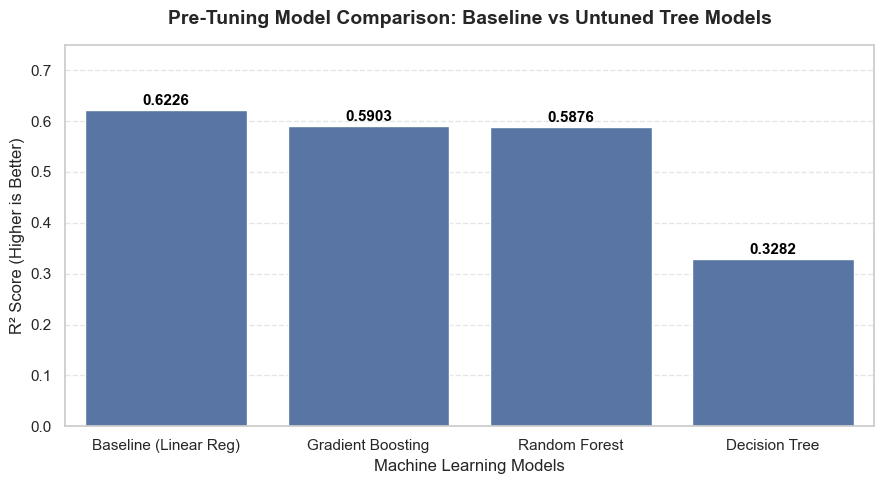

In [122]:
# Create a dictionary with your exact current results
pre_tune_r2 = {
    'Baseline (Linear Reg)': 0.6226,
    'Gradient Boosting': 0.5903,
    'Random Forest': 0.5876,
    'Decision Tree': 0.3282
}

# Convert to a clean DataFrame
df_pre_tune = pd.DataFrame(list(pre_tune_r2.items()), columns=['Model', 'R² Score'])

# Plot the bar chart
plt.figure(figsize=(9, 5))
df_pre_tune = df_pre_tune.sort_values(by='R² Score', ascending=False)

sns.barplot(x='Model', y='R² Score', data=df_pre_tune)

# Add data labels on top of each bar (FIXED LAYER)
for index, row in enumerate(df_pre_tune.itertuples()):
    plt.text(index, row[2] + 0.01, f"{row[2]:.4f}", color='black', ha="center", fontsize=11, fontweight='bold')

plt.title('Pre-Tuning Model Comparison: Baseline vs Untuned Tree Models', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('R² Score (Higher is Better)', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylim(0, 0.75) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the plot for your report and LinkedIn post
plt.savefig('pre_tuning_comparison.png')
plt.show()

*Figure 1.0: Pre-Tuning Coefficient of Determination ($R^2$) Comparison*

The visualization explicitly highlights that the baseline Linear Regression model yields the highest initial variance explanation ($R^2 = 0.6226$), outperforming the other models(untuned). This chart also illustrates that unconstrained tree-based algorithms overfit the data structure, resulting in lower generalization capabilities on unseen testing data before hyperparameter tuning is applied.

### HYPERPARAMETER TUNING 

### using GridSearchCV

In [123]:
# Define a controlled grid to prevent overfitting
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],  # Keeping trees shallow to combat overfitting
    'min_samples_split': [4, 6]
}

print("Tuning Gradient Boosting Regressor...")
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42), 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Extract and evaluate the best model
tuned_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}\n")

evaluate_model('Tuned Gradient Boosting', y_test, tuned_model.predict(X_test))

Tuning Gradient Boosting Regressor...
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 4, 'n_estimators': 50}

--- Tuned Gradient Boosting ---
RMSE: 1,433,722.45 | R² Score: 0.5933


the Tuned Gradient Boosting model improved its $R^2$ score to 0.5933 and reduced the Root Mean Squared Error (RMSE) down to 1,433,722.45 (dropping over 5,000 units of error from the untuned version).

### PRINT COMPARISON MATRIX

In [124]:
df_compare = pd.DataFrame(results).T
print("\n=== FINAL MODEL PERFORMANCE COMPARISON ===")
print(df_compare[['MAE', 'RMSE', 'R²']])


=== FINAL MODEL PERFORMANCE COMPARISON ===
                                 MAE         RMSE   R²
Baseline (Linear Reg)   1,029,010.29 1,381,117.65 0.62
Decision Tree           1,358,952.60 1,842,739.80 0.33
Random Forest           1,065,957.23 1,443,776.77 0.59
Gradient Boosting       1,040,051.69 1,439,009.70 0.59
Tuned Gradient Boosting 1,064,053.94 1,433,722.45 0.59


### Model Performance Graph

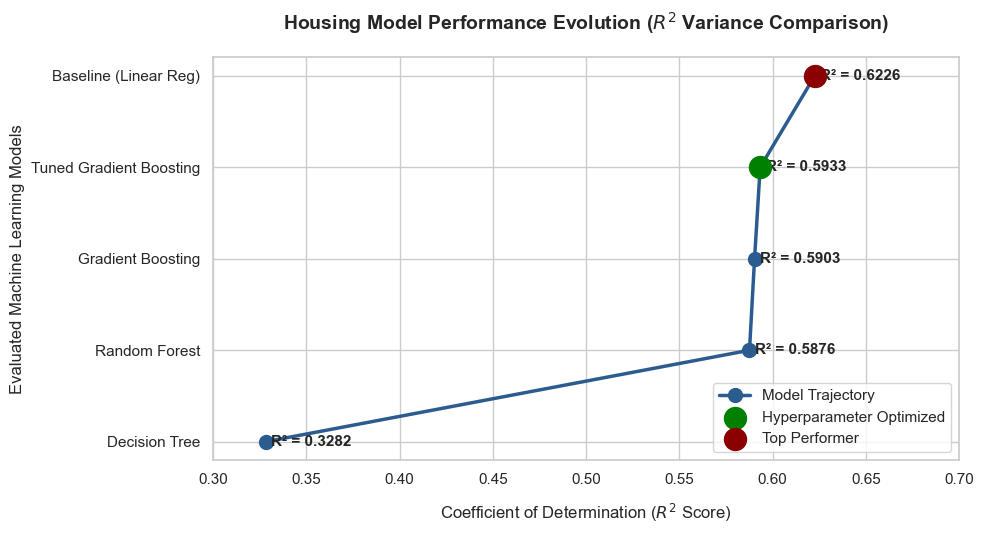

In [126]:
#  Using the result unrounded numbers
models = [
    'Decision Tree', 
    'Random Forest', 
    'Gradient Boosting', 
    'Tuned Gradient Boosting', 
    'Baseline (Linear Reg)'
]
r2_scores = [0.328194, 0.587603, 0.590321, 0.593326, 0.622622]

# 2. Set style and build the plot
plt.figure(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

# Plot the trajectory line showing performance climbing toward baseline
plt.plot(r2_scores, models, marker='o', markersize=10, linewidth=2.5, color='#2b5c8f', label='Model Trajectory')

# Color highlight specifically for your optimization step
plt.scatter(0.593326, 'Tuned Gradient Boosting', color='green', s=250, zorder=5, label='Hyperparameter Optimized')
plt.scatter(0.622622, 'Baseline (Linear Reg)', color='darkred', s=250, zorder=5, label='Top Performer')

# 3. Add data labels with full 4-decimal precision next to each point
for i, txt in enumerate(r2_scores):
    plt.text(txt + 0.003, i, f"R² = {txt:.4f}", va='center', fontsize=11, fontweight='bold')

# 4. Professional chart styling
plt.title('Housing Model Performance Evolution ($R^2$ Variance Comparison)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Coefficient of Determination ($R^2$ Score)', fontsize=12, labelpad=10)
plt.ylabel('Evaluated Machine Learning Models', fontsize=12)

# FIXED LAYER: Starting at 0.30 to eliminate empty left space
plt.xlim(0.30, 0.70)  

plt.legend(loc='lower right', frameon=True)
plt.tight_layout()

# Save for your presentation deliverables
plt.savefig('model_r2_improvement_trajectory.png', dpi=300)
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Key Findings

### Best Performing Model

Among all the models tested, the Linear Regression model produced the best results on the Housing Prices dataset. It achieved the lowest RMSE (1,381,117.65) and the highest R² Score (0.6226).

This means that the model was able to explain approximately 62.3% of the variation in house prices while maintaining the lowest prediction error among the models evaluated.

### Model Comparison

The Decision Tree model recorded the weakest performance, with an RMSE of 1,842,739.80 and an R² Score of 0.3282. This suggests that the model struggled to generalize well to unseen data and may have overfitted the training set.

Both the Random Forest and Gradient Boosting models performed better than the Decision Tree model. Their RMSE values were lower and their R² Scores were close to 0.59, showing that ensemble methods improved prediction accuracy by combining the strengths of multiple decision trees.

After applying hyperparameter tuning using GridSearchCV, the Gradient Boosting model showed a small improvement in performance. The RMSE decreased from 1,439,009.70 to 1,433,722.45, while the R² Score increased from 0.5903 to 0.5933.

## Key Insight

The results indicate that the Housing Prices dataset contains mostly linear relationships between the selected features and house prices. Because of this, the Linear Regression model was able to perform better than the more complex machine learning models.

This demonstrates that a more advanced algorithm does not always guarantee better performance. Selecting the right model depends on the characteristics of the dataset.

----------------------------------------------------------------------------------------------------------------------------------------------------------

# Conclusion

This project compared the performance of several machine learning models for predicting house prices, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and Tuned Gradient Boosting.

Based on the evaluation results, Linear Regression achieved the best overall performance, with the lowest RMSE and the highest R² Score. Although the advanced machine learning models performed reasonably well, none of them outperformed the baseline model on this dataset.

The findings show that the relationship between the selected housing features and house prices is largely linear. As a result, the simpler Linear Regression model was able to make more accurate predictions than the more complex models.

# Recommendation

For this dataset, Linear Regression is recommended as the preferred model for house price prediction because it provides the best balance between accuracy, simplicity, and interpretability.

Future studies could explore additional housing features, larger datasets, or advanced algorithms such as XGBoost and LightGBM to determine whether further improvements in predictive performance can be achieved.